# Member 4 — RandomForest
Herath H.M.H.D.P. · IT25100252

Created by Kaveesha Tennakoon. The saved test set has been used in earlier versions; use it as a reproducible benchmark, not untouched external validation.

## 01 · Load raw cleaned feature rows and fixed split

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))


Raw / clean / train / test: 100000 96146 76916 19230


## 02 · Inspect the full preprocessing recipe
Every fold fits its own imputation, optional BMI bounds, scaler and encoder. No globally processed matrix enters CV.

In [2]:
import inspect
print(inspect.getsource(RawPreparation))
display(make_preprocessor())

class RawPreparation(TransformerMixin,BaseEstimator):
    """Learn imputations and optional BMI bounds, then derive features from the transformed inputs.
    No target is accepted as an input feature. Binary and nominal features are never IQR capped.
    """
    def __init__(self,representation='original'):
        self.representation=representation
    def fit(self,X,y=None):
        X=self._validate(X)
        self.feature_names_in_=np.array(INPUTS,dtype=object)
        self.n_features_in_=len(INPUTS)
        self.medians_=X[CONT].median()
        self.modes_={c:X[c].mode().iloc[0] for c in CAT+BINARY}
        bmi=X.bmi.fillna(self.medians_['bmi'])
        q1,q3=bmi.quantile([.25,.75]);iqr=q3-q1
        self.bmi_bounds_=(float(q1-1.5*iqr),float(q3+1.5*iqr))
        self.fit_rows_=len(X)
        return self
    def _validate(self,X):
        if not isinstance(X,pd.DataFrame):raise TypeError('Pass raw inputs as a pandas DataFrame.')
        if 'diabetes' in X.columns:raise ValueError('

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepare', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,representation,'original'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the out

## 03 · Define six genuinely different candidates
P1: original features, no capping. P2: BMI capping + derived features. Three parameter settings each. Uniform class weighting preserves empirical prevalence; unlike the old balanced-weight runs, scores are therefore not a controlled preprocessing-only comparison. No threshold tuning.

In [3]:
member=4
model,parameter_grid=model_and_grid(member)
pipeline=Pipeline([("preprocess",make_preprocessor()),("model",model)])
display(pd.DataFrame(parameter_grid))

,preprocess__prepare__representation,model__max_depth,model__min_samples_leaf
0,[original],[8],[10]
1,[original],[14],[5]
2,[original],[None],[2]
3,[engineered_bmi_capped],[8],[10]
4,[engineered_bmi_capped],[14],[5]
5,[engineered_bmi_capped],[None],[2]


## 04 · Tune with 3-fold stratified cross-validation
Primary selection: mean validation F1. Also record precision, recall, accuracy, ROC-AUC and average precision. Fold SD is variability across folds, not a confidence interval. Six candidates × three folds = 18 CV fits, then one refit on all training rows. MLP early stopping is disabled so an internal validation split cannot inherit pre-fitted preprocessing.

In [4]:
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED)
search=GridSearchCV(pipeline,parameter_grid,cv=cv,
    scoring={'f1':'f1','precision':'precision','recall':'recall','accuracy':'accuracy','roc_auc':'roc_auc','average_precision':'average_precision'},
    refit='f1',n_jobs=1,return_train_score=True,error_score='raise',verbose=1)
with warnings.catch_warnings(record=True) as observed_warnings:
    warnings.simplefilter('always')
    search.fit(X_train,y_train)
warning_text='\n'.join(sorted(set(str(w.message) for w in observed_warnings)))
(PROJECT_ROOT/f'results/logs/m{member}_warnings.txt').write_text(warning_text or 'No warnings captured.')
print('Best CV F1:',search.best_score_,'Parameters:',search.best_params_)
print(warning_text or 'No warnings captured.')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best CV F1: 0.8009605638874198 Parameters: {'model__max_depth': 14, 'model__min_samples_leaf': 5, 'preprocess__prepare__representation': 'original'}
No warnings captured.


## 05 · Show candidates, test evaluation and fitted pipeline export
Test is used after this notebook has selected its candidate. Group presentation recommendation is selected by CV F1, not test ranking. This module writes CSV/JSON evidence, annotated figures and a raw-input joblib pipeline.

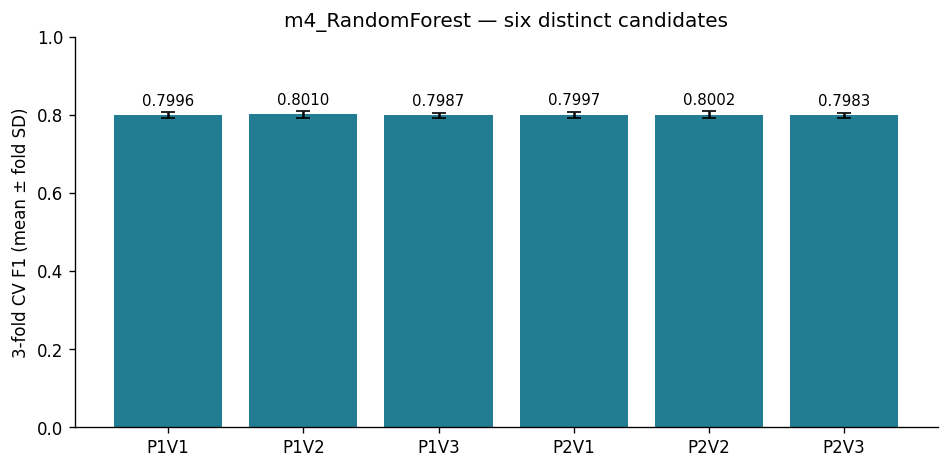

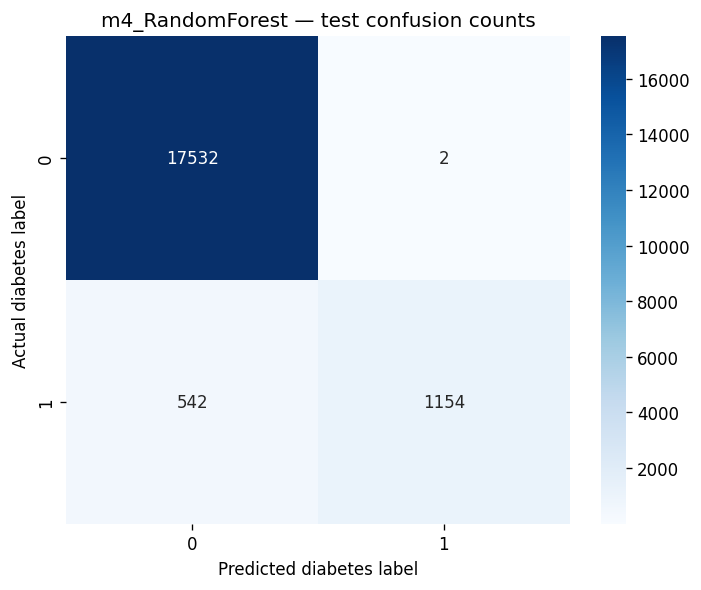

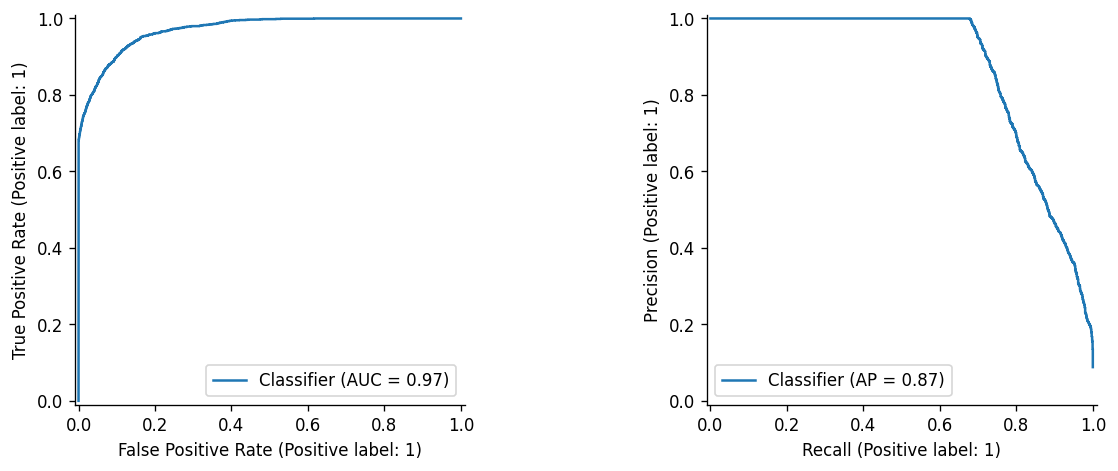

,candidate,params,mean_test_f1,std_test_f1,mean_test_recall,mean_test_precision
0,P1V1,"{'model__max_depth': 8, 'model__min_samples_le...",0.799621,0.008543,0.666225,1.000000
1,P1V2,"{'model__max_depth': 14, 'model__min_samples_l...",0.800961,0.007988,0.669467,0.996960
2,P1V3,"{'model__max_depth': None, 'model__min_samples...",0.798684,0.006900,0.674035,0.980158
3,P2V1,"{'model__max_depth': 8, 'model__min_samples_le...",0.799729,0.008402,0.666372,1.000000
4,P2V2,"{'model__max_depth': 14, 'model__min_samples_l...",0.800242,0.009291,0.671235,0.990872
5,P2V3,"{'model__max_depth': None, 'model__min_samples...",0.798281,0.006590,0.679635,0.967367


,member,model,kind,selected,cv_f1,cv_f1_std,params,features,accuracy,precision,recall,f1,roc_auc,average_precision,tn,fp,fn,tp,iterations,hit_iteration_limit
0,4,RandomForest,classifier,P1V2,0.800961,0.007988,"{'model__max_depth': 14, 'model__min_samples_l...",15,0.971711,0.99827,0.680425,0.809257,0.971179,0.873585,17532,2,542,1154,None,False


In [5]:
result,candidates=finalize_classifier(PROJECT_ROOT,member,search,X_test,y_test)
display(candidates[["candidate","params","mean_test_f1","std_test_f1","mean_test_recall","mean_test_precision"]])
display(pd.DataFrame([result]))

## 06 · Verify raw-input inference after reload
Load only trusted artifacts made by this project. Keep `src/project_core.py` and matching dependency versions alongside the model.

In [6]:
saved=joblib.load(PROJECT_ROOT/f"models/m{member}_{MODELS[member]}_pipeline.joblib")
example=X_test.head(3)
display(example)
print("Predictions:",saved.predict(example))
assert np.array_equal(saved.predict(example),search.best_estimator_.predict(example))

Predictions: [0 0 0]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
2,Male,28.0,0,0,never,27.32,5.7,158
5,Female,20.0,0,0,never,27.32,6.6,85
16,Male,15.0,0,0,never,30.36,6.1,200
